# Stochastics
This is one of the most important disciplines in modern finance. Today, not only is the correct valuation of single financial instruments important to participants in the financial markets, but also the consistent valuation of whole derivatives books. Flexible, efficient numerical methods need to be implemented in order to keep up with the demand of risk measurements and transparency of financial institutions. Here we will look at a few concepts from the pythonic perspective:
- Random Numbers
- Simulation
- Valuation
- Risk Measures

In [1]:
%%html
<style>
table {float:left}
</style>

## Random Numbers
Numpy will be used as the scientific library for producing random numbers in this notebook, there is a subpackaged called numpy.random:

In [2]:
import math
import numpy as np
import numpy.random as npr
from pylab import plt, mpl

In [3]:
plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

The rand() function returns random numbers from the open interval $[0, 1)$ in the shape provided as a parameter to the function. The return object is an ndarray object. Such numbers can be easily transformed to cover other intervals of the **real line**. For instance, if one wants to generate random numbers from the interval $[a,b) = [5,10)$, one can transform the returned numbers from npr.rand() as in the next example -- this also works in multiple dimensions due to NumPy broadcasting:

In [4]:
npr.seed(100)
np.set_printoptions(precision=4)

In [5]:
npr.rand(10)

array([0.5434, 0.2784, 0.4245, 0.8448, 0.0047, 0.1216, 0.6707, 0.8259,
       0.1367, 0.5751])

In [6]:
npr.rand(5, 5)

array([[0.8913, 0.2092, 0.1853, 0.1084, 0.2197],
       [0.9786, 0.8117, 0.1719, 0.8162, 0.2741],
       [0.4317, 0.94  , 0.8176, 0.3361, 0.1754],
       [0.3728, 0.0057, 0.2524, 0.7957, 0.0153],
       [0.5988, 0.6038, 0.1051, 0.3819, 0.0365]])

In [7]:
a = 5.
b = 10.
npr.rand(10) * (b - a) + a

array([9.4521, 9.9046, 5.2997, 9.4527, 7.8845, 8.7124, 8.1509, 7.9092,
       5.1022, 6.0501])

In [8]:
npr.rand(5, 5) * (b - a) + a

array([[7.7234, 8.8456, 6.2535, 6.4295, 9.262 ],
       [9.875 , 9.4243, 6.7975, 7.9943, 6.774 ],
       [6.701 , 5.8904, 6.1885, 5.2243, 7.5272],
       [6.8813, 7.964 , 8.1497, 5.713 , 9.6692],
       [9.7319, 8.0115, 6.9388, 6.8159, 6.0217]])

*Table 12-1. Functions for simple random number generation*

| Function       | Parameters       | Returns/result
| ---------------| -----------------|-----------------
| rand           | d0, d1, ..., dn  | Random values in the given shape
| randn          | d0, d1, ..., dn  | A sample (or samples) from the standard normal distribution
| randint        | low[, high, size]| Random integers from low (inclusive) to high (exclusive) 
| random_integers| low[, high, size]| Random integers between low and high, inclusive
| random_sample  | [size]           | Random floats in the half-open interval $[0.0, 1.0)$ 
| random         | [size]           | Random floats in the half-open interval $[0.0, 1.0)$ 
| ranf           | [size]           | Random floats in the half-open interval $[0.0, 1.0)$ 
| sample         | [size]           | Random floats in the half-open interval $[0.0, 1.0)$ 
| choice         | [size]           | Random sample from a given 1D array
| bytes          | [size]           | Random bytes

It is pretty straightforward to now visualize random draws generated by selected functions from Table 12-1. Here we'll show graphical results for two continuous distributions and two discrete ones:

In [9]:
sample_size = 500
rn1 = npr.rand(sample_size, 3)
rn2 = npr.randint(0, 10, sample_size)
rn3 = npr.sample(size=sample_size)
a = [0, 25, 50, 75, 100]
rn4 = npr.choice(a, size=sample_size)

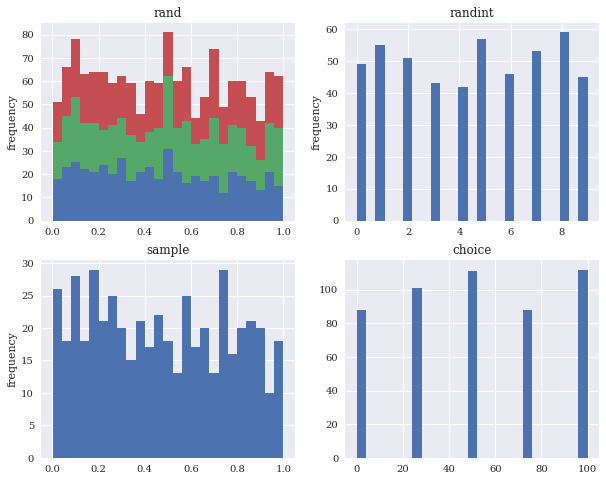

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax1.hist(rn1, bins=25, stacked=True)
ax1.set_title('rand')
ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25)
ax2.set_title('randint')
ax2.set_ylabel('frequency')
ax3.hist(rn3, bins=25)
ax3.set_title('sample')
ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25)
ax4.set_title('choice');

*Table 12-2. Functions for generating random numbers according to different distributions*

| Function            | Parameters                  | Returns/result
| --------------------|-----------------------------|-----------------
| beta                | $a, b[,size]$               | Samples for a beta distribution over $[0,1)$
| binomial            | $n, p[,size]$               | Samples from binomial distribution
| chisquare           | $df[,size]$                 | Samples from chi-square distribution
| dirichlet           | $alpha[,size]$              | Samples from the Dirichlet distribution
| exponential         | $[scale, size]$             | Samples from the exponential distribution
| f                   | $dfnum, dfden[,size]$       | Samples from the F distribution 
| gamma               | $shape[,scale, size]$       | Samples from the gamma distribution
| geometric           | $p[,size]$                  | Samles from the geometric distribution 
| gumbel              | $[loc,scale,size]$          | Samples from the Gumbel distribution
| hypergeometric      | $ngood,nbad,nsample[,size]$ | Samples from a hypergeometric distribution
| laplace             | $[loc,scale,size]$          | Samples from the Laplace or double exponential distribution
| logistic            | $[loc,scale,size]$          | Samples from  a logistic distribution
| lognormal           | $[mean,sigma,size]$         | Samples from a log-normal distribution
| logseries           | $p[,size]$                  | Samples from a logarithmic series distribution
| multinomial         | $n,pvals[,size]$            | Samples from a multinomial distribution
| multivariate_normal | $mean,cov[,size]$           | Samples from a multivariate normal distribution
| negative_binomial   | $n,p[,size]$                | Samples from a negative binomial distribution
| noncentral_chisquare| $df,nonc[,size]$            | Samples from a noncentral chi-square distribution
| noncentral_f        | $dfnum,dfden,nonc[,size]$   | Samples from the noncentral F distribution
| normal              | $[loc,scale,size]$          | Samples from a normal (Gaussian) distribution
| pareto              | $a[,size]$                  | Samples from a Pareto II or Lomax distribution with the specified shape
| poisson             | $[lam,size]$                | Samples from a Poisson distribution
| power               | $a[,size]$                  | Samples in $[0,1)$ from a power distribution with positive exponent a-1
| rayleigh            | $[scale,size]$              | Samples from a Rayleigh distribution
| standard_cauchy     | $[size]$                    | Samples from a standard Cauchy distribution with mode=0
| standard_exponential| $[size]$                    | Samples from the standard exponential distribution
| standard_gamma      | $shape[size]$               | Samples from a standard gamma distribution
| standard_normal     | $[size]$                    | Samples from a standard normal distribution (mean=0, std=1)
| standard_t          | $df[,size]$                 | Samples from a Student's t distribution with df degrees of freedom
| triangular          | $left,mode,right[,size]$    | Samples from the triangular distribution over the interval $[left,right]$
| uniform             | $[low,high,size]$           | Samples from a uniform distribution
| vonmises            | $mu,kappa[,size]$           | Samples from a von Mises distribution
| wald                | $mean,scale[,size]$         | Samples from a Wald, or inverse Gaussian, distribution
| weibull             | $a[,size]$                  | Samples from a Weibull distribution
| zipf                | $a[,size]$                  | Samples from a Zipf distribution


There is a lot of criticism surrounding the use of (standard) normal distributions in finance, yet they are an indispensable tool. They are still the most widely used type of distribution, in analytical and numerical appications. One of the reasons for this is that many financial models directly rest in one way or another on a normal distribution or a log-normal distribution. Another reason is that many financial models that do not rest directly on a (log-)normal assumption can be discretized, and therewith approximated for simulation purposes, by the use of the normal distribution. 

Consider the following, which visualizes random draws from the following distributions:
- *Standard normal with mean of 0 and standard deviation of 1*
- *Normal with mean of 100 and standard deviation of 20*
- *Chi square with 0.5 defrees of freedom*
- *Poisson with lambda of 1*

In [11]:
sample_size = 500
rn1 = npr.standard_normal(sample_size)
rn2 = npr.normal(100, 20, sample_size)
rn3 = npr.chisquare(df=0.5, size=sample_size)
rn4 = npr.poisson(lam=1.0, size=sample_size)

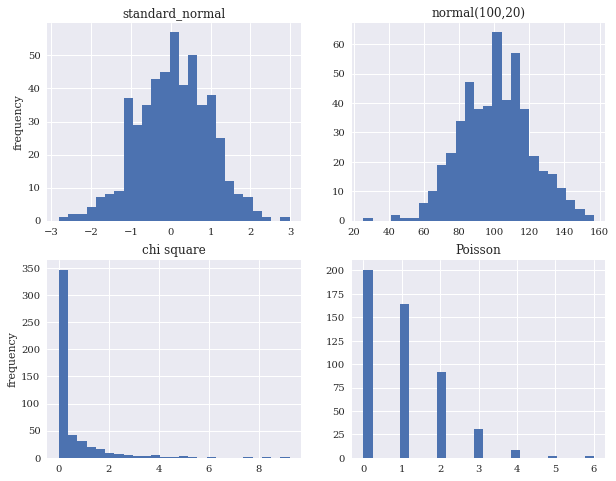

In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax1.hist(rn1, bins=25)
ax1.set_title('standard_normal')
ax1.set_ylabel('frequency')
ax2.hist(rn2, bins=25)
ax2.set_title('normal(100,20)')
ax3.hist(rn3, bins=25)
ax3.set_title('chi square')
ax3.set_ylabel('frequency')
ax4.hist(rn4, bins=25)
ax4.set_title('Poisson');

## Simulation
Monte Carlo simulation (MCS) is among the most important numerical techniques in finance, if not *the* most important and widely used. This mainly stems from the fact that it is the most flexible numerical method when it comes to the evalutation of mathematical expressions (e.g., integrals), and specifically the valuation of financial derivatives. The flexibility comes at the cost of a relatively high computational burden, though, since often hundreds of thousands or even millions of complex computations have to be carried out to come up with a single value estimate.

### Random Variables
Consider the Black-Scholes-Merton setup for option pricing. The level of a stock index $S_{T}$ at a future date *T* given a level $S_{0}$ as of today is given according to Equation 12-1.

Equation 12-1:

$S_{T} = S_{0}exp((r - \frac{1}{2}\sigma^{2})T + \sigma\sqrt{T_{Z}})$

$S_{T}$: index level at date *T*

$r$: Constant riskless short rate

$\sigma$: Constant volatility (= standard deviation of returns) of *S*

$z$: Standard normally distributed random variable

In [13]:
# initial index level
S0 = 100
# riskless short rate
r = 0.05
# constant volatility factor
sigma = 0.25
# the horizon in year fractions
T = 2.0
# number of simulations
I = 10000
# simulation
ST1 = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * math.sqrt(T) * npr.standard_normal(I))

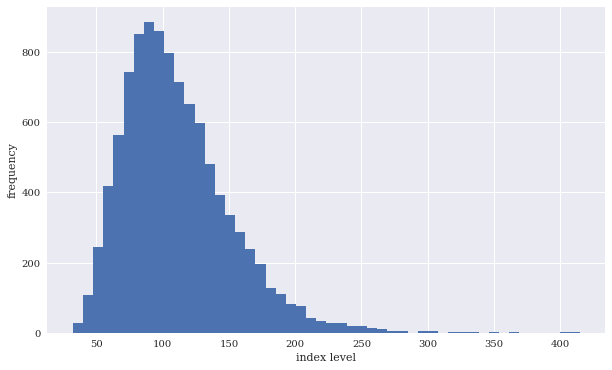

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(ST1, bins=50)
plt.xlabel('index level')
plt.ylabel('frequency');

*Figure 12-3. Statistically simulated geometric Brownian motion (via npr.standard_normal())*

The figure suggests that the distribution of the random variable as defined in Equation 12-1 is *log-normal*. One could therefore also try to use the npr.lognormal() function to directly derive the values for the random variable. In that case, one has to provide the mean and the standard normal deviation to the function:

In [15]:
ST2 = S0 * npr.lognormal((r - 0.5 * sigma ** 2) * T, sigma * math.sqrt(T), size=I)

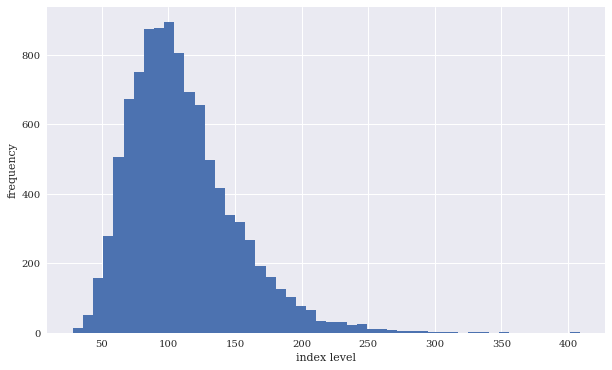

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(ST2, bins=50)
plt.xlabel('index level')
plt.ylabel('frequency');

*Figure 12-4. Statically simulated geometric Brownian motion (via npr.lognormal())*

Figures 12-3 and 12-4 look pretty similar. They are able to be compared at a more in depth level by comparing statistical moments of the resulting distributions. To compare the distributional characteristics of simulation results, the scipy.stats subpackage and helper function print_statistics() can be incredibly useful.

In [17]:
import scipy.stats as scs

def print_statistics(a1, a2):
    ''' Prints selected statistics
    
    Parameters
    ==========
    a1, a2: ndarray objects
        results objects from simulation
    '''
    sta1 = scs.describe(a1)
    sta2 = scs.describe(a2)
    print('%14s %14s %14s' %
         ('statisctic', 'data set 1', 'data set 2'))
    print(45 * "-")
    print('%14s %14.3f %14.3f' % ('size', sta1[0], sta2[0]))
    print('%14s %14.3f %14.3f' % ('min', sta1[1][0], sta2[1][0]))
    print('%14s %14.3f %14.3f' % ('max', sta1[1][1], sta2[1][1]))
    print('%14s %14.3f %14.3f' % ('mean', sta1[2], sta2[2]))
    print('%14s %14.3f %14.3f' % ('std', np.sqrt(sta1[3]),
                                 np.sqrt(sta2[3])))
    print('%14s %14.3f %14.3f' % ('skew', sta1[4], sta2[4]))
    print('%14s %14.3f %14.3f' % ('kurtosis', sta1[5], sta2[5]))

In [18]:
print_statistics(ST1, ST2)

    statisctic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         32.327         28.230
           max        414.825        409.110
          mean        110.730        110.431
           std         40.300         39.878
          skew          1.122          1.115
      kurtosis          2.438          2.217


The differences in these two data sets are mainly due to *sampling error* in the simulation, they are obviously very similar. Another error can be introduced when *discretely* simulating *continuous* stochastic processes -- namely the *discretization error*, which plays no role in this example due to the static nature of the simulation approach.

## Stochastic Processes
Roughly speaking, a *stochastic process* is a sequence of random variables. In that sense, one should expect something similar to a sequence of repeated simulations of a random variable when simulating a process. This is mainly true, apart from the fact that the draws are typically not independent but rather depend on the result(s) of the previous draw(s). In general, however, stochastic processes used in finance exhibit the *Markov property*, which mainly says that tomorrow's value of the process only depends on today's state of the process, and not any other more "historic" state or even the whole path history. The process then is alsocalled *memoryless*.

### Geometric Brownian Motion
Consider now theBlack-Scholes-Merton model in its dynamic form, as described by the stochastic differential equation (SDE) in Equation 12-2. Here $Z_t$ is a standard Brownian motion. The SDE is called a *geometric Brownian motion*. The values of $S_t$ are log-normally distributed and the (marginal) returns $\frac{dS_t}{S_t}$ normally.

*Equation 12-2. Stochastic differential equation in Black-Scholes-Merton setup*

$dS_t = rS_tdt + \sigma S_tdZ_t$

The SDE in Equation 12-2 can be discretized exactly by an Euler scheme. Such a scheme is presented in Equation 12-3, with $\delta t$ being the fixed discretization interval and $z_t$ being a standard normally distributed random variable.

*Equation 12-3. Simulating index levels dynamically in Black-Scholes-Merton setup*

$S_t = S_{t - \Delta t} exp((r - \frac{1}{2}\sigma ^2) \Delta t + \sigma \sqrt{\Delta tz_i})$

As shown before, translation into Python and NumPy code is straightforward. The resulting end values for the index level are log-normally distributed again, as Figure 12-5 illustrates. The first four moments are also quire close to those resulting from the static simulation approach:

In [19]:
I = 10000
M = 50
dt = T / M
S = np.zeros((M + 1, I))
S[0] = S0

for t in range(1, M + 1):
    S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * math.sqrt(dt) * npr.standard_normal(I))

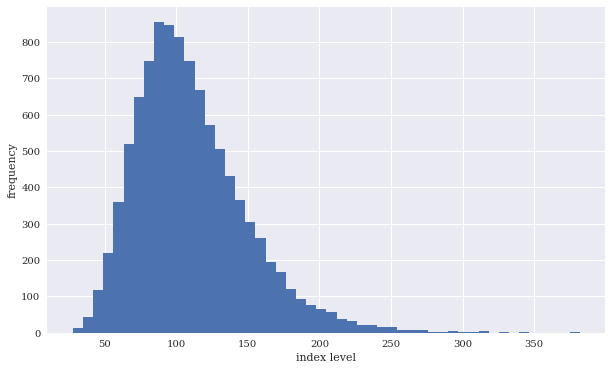

In [20]:
plt.figure(figsize=(10,6))
plt.hist(S[-1], bins=50)
plt.xlabel('index level')
plt.ylabel('frequency');

*Figure 12-5. Dynamically simulated geometric Brownian motion at maturity*

Below is a comparison of the statistics resulting from the dynamic simulation as well as from the static simulation. Figure 12-6 shows the first 10 simulated paths:

In [21]:
print_statistics(S[-1], ST2)

    statisctic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         27.746         28.230
           max        382.096        409.110
          mean        110.423        110.431
           std         39.179         39.878
          skew          1.069          1.115
      kurtosis          2.028          2.217


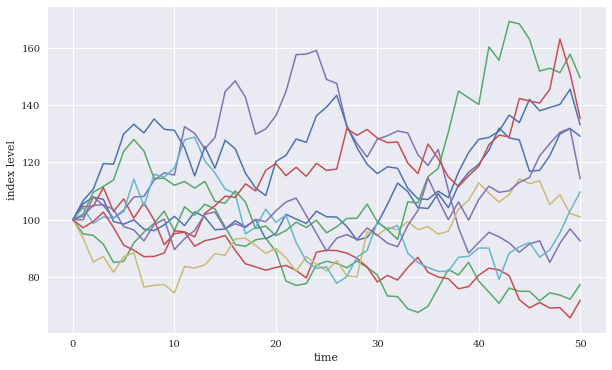

In [22]:
plt.figure(figsize=(10,6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level');

*Figure 12-6. Dynamically simulated geometric Brownian motion paths*

Using the dynamic simulation approach not only allows us to visualize paths as displayed in Figure 12-6, but also to value options with American/Bermudan exercise or options whose payoff is path-dependent. One gets the full dynamic picture over time, so to say.

## Square-root diffusion
Another important class of financial processes is *mean-reverting processes*, which are used to model short rates or volatility processes, for example. A popular and widely used model is the *square-root diffusion*, as proposed by Cox, Ingersoll, and Ross (1985). Equation 12-4 provides the respective SDE.

*Equation 12-4. Stochastic differential equation for square-root diffusion*

$dx_t = k(\theta - x_t)dt + \sigma \sqrt{x_t}dZ_t$

$x_t$: Process level at date *t*

$k$: Mean-reversion factor

$\theta$: Long-term mean of the process

$\sigma$: Constant volatility parameter

$Z_t$: Standard Brownian motion

It is well known that the values of $x_t$ are chi-squared distributed. However, as stated before, many financial models can be discretized and approximated by using the normal distribution (i.e., a so-called Euler discretization scheme). While the Euler scheme is exact for the geometric Brownian motion, it is biased for the majority of other stochastic processes. Even if there is an exact scheme available -- one for the square-root diffusion will be presented later -- the use of an Euler scheme might be desirable for numerical and/or computational reasons. Defining $s = t - \Delta t$ and $x^+ \equiv max(x,0)$, Equation 12-5 presents such an Euler scheme. This particular one is generally called *full truncation* in the literature (see Hilpsch (2015) for more details and other schemes).

*Equation 12-5. Euler discretization for square-root diffusion*

$\tilde{x_t} =  \tilde{x_s} + k(\theta - \tilde{x^+_s})\Delta t + \sigma \sqrt{\tilde{x^+_s}} \sqrt{\Delta t}z_t$

$x_t = \tilde{x^+_t}$

The square-root diffusion has the convenient and realistic characteristic that the values of $x_t$ remain strictly positive. When discretizing it by an Euler scheme, negative values cannot be excluded. That is the reason why one works always with the positive version of the originally simulated process. In the simulation code, one therefore needs two ndarray objects instead of only one. Figure 12-7 shows the result of the simulation graphically as a histogram:

In [23]:
x0 = 0.05
kappa = 3.0
theta = 0.02
sigma = 0.1
I = 10000
M = 50
dt = T / M

In [24]:
def srd_euler():
    xh = np.zeros((M + 1, I))
    x = np.zeros_like(xh)
    xh[0] = x0
    x[0] = x0
    for t in range(1, M + 1):
        xh[t] = (xh[t - 1] + 
                kappa * (theta - np.maximum(xh[t - 1], 0)) * dt +
                sigma * np.sqrt(np.maximum(xh[t - 1], 0)) * 
                math.sqrt(dt) * npr.standard_normal(I))
    x = np.maximum(xh, 0)
    return x

x1 = srd_euler()

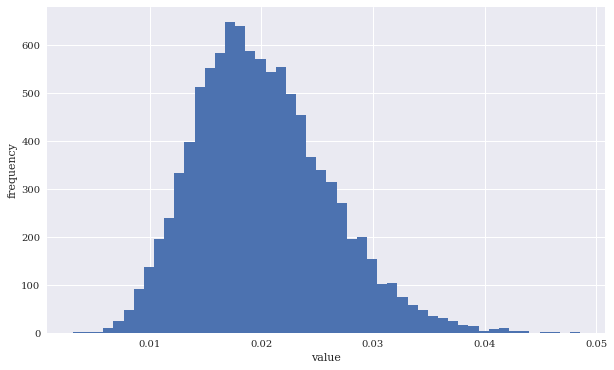

In [25]:
plt.figure(figsize=(10,6))
plt.hist(x1[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency');

*Figure 12-7. Dynamically simulated square-root diffusion at maturity (Euler scheme)*

Figure 12-8 then shows the first 10 simulated paths, illustrating the resulting negative average drift (due to $x_0 > \theta$) and the convergence to $\theta = 0.02$:

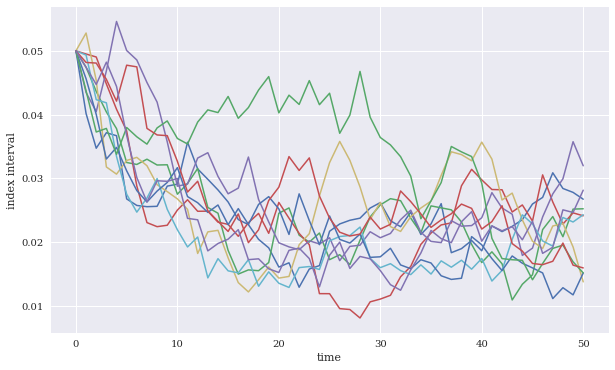

In [26]:
plt.figure(figsize=(10,6))
plt.plot(x1[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index interval');

*Figure 12-8. Dynamically simulated square-root diffusion paths (Euler scheme)*

Equation 12-6 presents the exact discretization scheme for the square-root diffusion based on the noncentral chi-square distribution $\chi ^{'2}_d$ with

$df = \frac{4\theta k}{\sigma ^2}$

degrees of freedom and noncentrality parameter

$nc = \frac{4ke^{-k\Delta t}}{\sigma ^2 (1 - e^{-k\Delta t})} x_s$

*Equation 12-6. Exact discretization for square-root diffusion*

$x_t = \frac{\sigma ^2(1 - e^{-k\Delta t})}{4k} \chi^{'2}_d (\frac{4ke^{-k\Delta t}}{\sigma ^2 (1 - e^{-k\Delta t})} x_s)$

The python implementation of this discretization scheme is a bit more involved but still concise. Figure 12-9 shows the output at maturity of the simulation with the exact scheme as a histogram:

In [27]:
def srd_exact():
    x = np.zeros((M + 1, I))
    x[0] = x0
    for t in range(1, M + 1):
        df = 4 * theta * kappa / sigma ** 2
        c = (sigma ** 2 * (1 - np.exp(-kappa * dt))) / (4 * kappa)
        nc = np.exp(-kappa * dt) / c * x[t - 1]
        x[t] = c * npr.noncentral_chisquare(df, nc, size=I)
    return x
x2 = srd_exact()

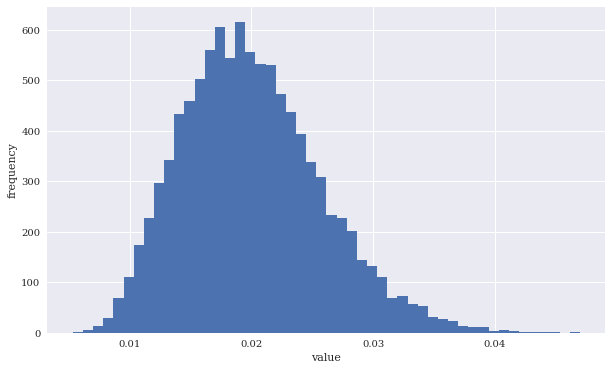

In [28]:
plt.figure(figsize=(10,6))
plt.hist(x2[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency');

*Figure 12-9. Dynamically simulated square-root diffusion at maturity (exact scheme)*

Figure 12-10 presents the first 10 simulated paths, again displaying the negative average drigt and the convergence to $\theta$:

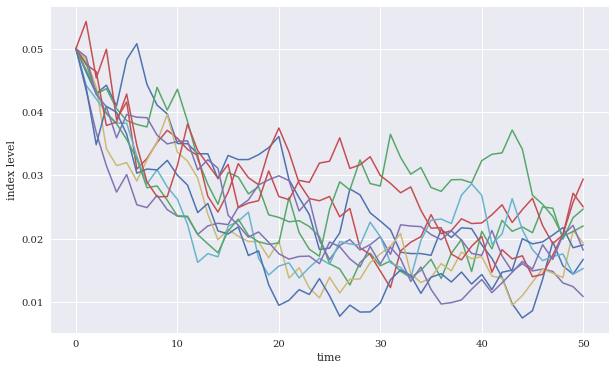

In [29]:
plt.figure(figsize=(10,6))
plt.plot(x2[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level');

*Figure 12-10. Dynamically simulated square-root diffusion paths (exact scheme)*

Comparing the main statistics from the different approaches reveals that the biased Euler scheme performs well when it comes to the desired statistical properties:

In [30]:
print_statistics(x1[-1], x2[-1])

    statisctic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min          0.003          0.005
           max          0.049          0.047
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.529          0.532
      kurtosis          0.289          0.273


In [31]:
I = 25000
%time x1 = srd_euler()

CPU times: user 78.1 ms, sys: 16.9 ms, total: 95 ms
Wall time: 110 ms


In [32]:
%time x2 = srd_exact()

CPU times: user 175 ms, sys: 4.69 ms, total: 180 ms
Wall time: 209 ms


In [33]:
print_statistics(x1[-1], x2[-1])

    statisctic     data set 1     data set 2
---------------------------------------------
          size      25000.000      25000.000
           min          0.004          0.004
           max          0.057          0.056
          mean          0.020          0.020
           std          0.006          0.006
          skew          0.584          0.579
      kurtosis          0.590          0.541


A major difference can be observed in terms of execution speed, since sampling from the noncentral chi-square distribution is more computationally demanding than from the standard normal distribution. The exact scheme takes roughly twice as much time for virtually the same results as with the Euler scheme.

## Stochastic Volatility
One of the major simplifying assumptions of the Black-Scholes-Merton model is the *constant volatility*. However, volatility in general is neither constant nor deterministic -- it is *stochastic*. Therefore, a major advancement with regard to financial modeling was achieved in the early 1990s with the introduction of so-called *stochastic volatility models*. One of the most popular models that fall into that category is that of Heston (1993), which is presented in Equation 12-7.

*Equation 12-7. Stochastic differential equations for Heston stochastic volatility model*

$dS_t = rS_t dt + \sqrt{v_t}S_t dZ^1_t$

$dv_t = k_v (\theta_v - v_t)dt + \sigma _v \sqrt{v_t}dZ^2_t$

$dZ^1_t dZ^2_t = \rho$

The meaning of the variables and parameters can now be inferred easily from the discussion of the geometric Brownian motion and the square-root diffusion. The parameter $\rho$ represents the instantaneous correlation between the two standard Brownian motions $Z^1_t$, $Z^2_t$. This allows us to account for a stylized fact called the *leverage effec*, which in essence states that volatility goes up in times of stress (declining markets) and goes down in times of a bull market (rising markets).

Consider the following parameterization of the model. To account for the correlation between the two stochastic processes, one needs to determine the Cholesky decomposition of the correlation matrix:

In [34]:
S0 = 100.
r = 0.05
# initial (instantaneous) volatility value
v0 = 0.1
kappa = 3.0
theta = 0.25
sigma = 0.1
# fixed correlation between the two Brownian motions
rho = 0.6
T = 1.0

In [35]:
corr_mat = np.zeros((2, 2))
corr_mat[0, :] = [1.0, rho]
corr_mat[1, :] = [rho, 1.0]
cho_mat = np.linalg.cholesky(corr_mat)

In [36]:
# cholensky decomposition and resulting matrix
cho_mat

array([[1. , 0. ],
       [0.6, 0.8]])

Before the start of the simulation of the stochastic processes the whole set of random numbers for both processes is generated, looking to use set 0 for the index process and set 1 for the volatility process. For the volatility process modeled by a square-root diffusion, the Euler scheme is chosen, taking into account the correlation via the Cholesky matrix:

In [37]:
M = 50
I = 10000
dt = T / M

In [38]:
# generates the 3D random number data set
ran_num = npr.standard_normal((2, M + 1, I))

In [39]:
v = np.zeros_like(ran_num[0])
vh = np.zeros_like(v)

In [40]:
v[0] = v0
vh[0] = v0

In [41]:
for t in range(1, M + 1):
    # picks out the relevant random number subset and transforms it via the Cholesky matrix
    ran = np.dot(cho_mat, ran_num[:, t, :])
    # simulates the paths based on an Euler scheme
    vh[t] = (vh[t - 1] + 
            kappa * (theta - np.maximum(vh[t - 1], 0)) * dt + 
            sigma * np.sqrt(np.maximum(vh[t - 1], 0)) * 
            math.sqrt(dt) * ran[1])

In [42]:
v = np.maximum(vh, 0)

The simulation of the index level process also takes into account the correlation and uses the (in this case) exact Euler scheme for the geometric Brownian motion. Figure 12-11 shows the simulation results at maturity as a histogram for both the index level process and the volatility process:

In [43]:
S = np.zeros_like(ran_num[0])
S[0] = S0
for t in range(1, M + 1):
    ran = np.dot(cho_mat, ran_num[:, t, :])
    S[t] = S[t - 1] * np.exp((r - 0.5 * v[t]) * dt + 
                            np.sqrt(v[t]) * ran[0] * np.sqrt(dt))

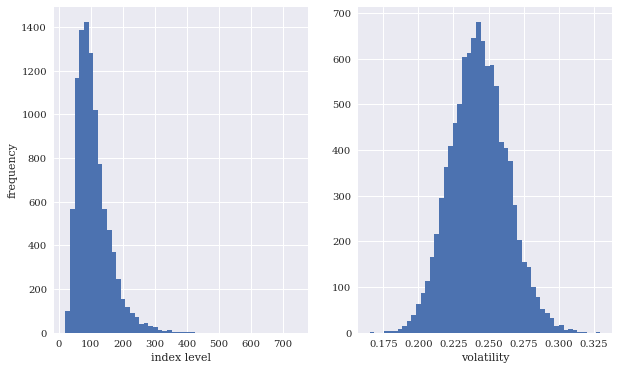

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.hist(S[-1], bins=50)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax2.hist(v[-1], bins=50)
ax2.set_xlabel('volatility');

*Figure 12-11. Dynamically simulated stochastic volatility process at maturity*

This illustrates another advantage of working with the Euler scheme for the square-root diffusion: *correlation is easily and consistently accounted for* since one only draws standard normally distributed random numbers. There is no simple way of achieving the same with a mixed approach (i.e., using Euler for the index and the noncentral chi-square-based exact approach for the volatility process).

An inspection of the first 10 simulated paths of each process (see Figure 12-12) shows that the volatility process is drifting positively on average and that it, as expected, converges to $\theta = 0.25$:

In [45]:
print_statistics(S[-1], v[-1])

    statisctic     data set 1     data set 2
---------------------------------------------
          size      10000.000      10000.000
           min         21.604          0.165
           max        740.474          0.330
          mean        108.393          0.243
           std         51.935          0.020
          skew          1.646          0.126
      kurtosis          5.750          0.045


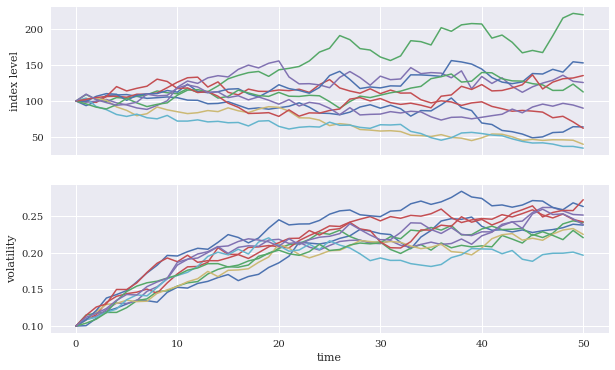

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))
ax1.plot(S[:, :10], lw=1.5)
ax1.set_ylabel('index level')
ax2.plot(v[:, :10], lw=1.5)
ax2.set_xlabel('time')
ax2.set_ylabel('volatility');

*Figure 12-12. Dynamicaly simulated stochastic volatility proess paths*

Having a brief look at the statistics for the maturity date for both data sets reveals a pretty high maximum value for the index level process. In fact, this is much higher than a geometric Brownian motion with constant volatility could ever climb, *ceteris paribus*.

## Jump diffusion
Stochastic volatility and the leverage effect are stylized (empirical) facts found in a number of markets. Another important stylized fact is the existence of *jumps* in asset prices and, for example, volatility. In 1976, Merton published his jump diffusion model, enhancing the Black-Scholes-Merton setup through a model component generating jumps with log-normal distribution. The risk-neutral SDE is presented in Equation 12-8.

*Equation 12-8. Stochastic differential equation for Merton jump diffusion model*

$dS_t = (r - r_j)S_tdt + \sigma S_tdZ_t + J_tS_tdN_t$

$S_t$: Index level at date *t*

$r$: Constant riskless short rate

$r_j \equiv \lambda \cdot (e^{\mu _j + \delta^{2/2}} - 1)$: Drift correction for jump to maintain risk neutrality

$\sigma$: Constant volatility of *S*

$Z_t$: Standard Brownian motion

$J_t$: Jump at date *t* with distribution $log(1 + J_t) \approx N(log (1 + \mu_J) - \frac{\delta^2}{2}, \delta^2)$ with **N** as the cumulative distribution function of a standard normal random variable
    
$N_t$: Poisson process with intensity $\lambda$

Equation 12-9 presents an Euler discretization for the jump diffusion where the $z^n_t$ are standard normally distributed and the $y_t$ are Poisson distributed with intensity $\lambda$.

*Equation 12-9. Euler discretization for Merton jump diffusion model*

$S_t = S_{t - \Delta t}(e^{(r - r_j - \sigma ^{2 /2})\Delta t + \sigma \sqrt{\Delta t}z^1_t} + (e^{\mu_J + \delta z^2_t} - 1)y_t)$

Given the discretization scheme, consider the following numerical parameterization:

In [47]:
S0 = 100.
r = 0.05
sigma = 0.2
# the jump intensity
lamb = 0.75
# mean jump size
mu = -0.6
# jump volatility
delta = 0.25
# drift correction
rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)

In [48]:
T = 1.0
M = 50
I = 10000
dt = T / M

In [49]:
S = np.zeros((M + 1, I))
S[0] = S0
# standard normally distributed random numbers
sn1 = npr.standard_normal((M + 1, I))
sn2 = npr.standard_normal((M + 1, I))
# poisson distributed random numbers
poi = npr.poisson(lamb * dt, (M + 1, I))
# simulation based on the exact Euler scheme
for t in range(1, M + 1, 1):
    S[t] = S[t - 1] * (np.exp((r - rj - 0.5 * sigma ** 2) * dt + 
                        sigma * math.sqrt(dt) * sn1[t]) + 
                        (np.exp(mu + delta * sn2[t]) - 1) * 
                        poi[t])
    S[t] = np.maximum(S[t], 0)

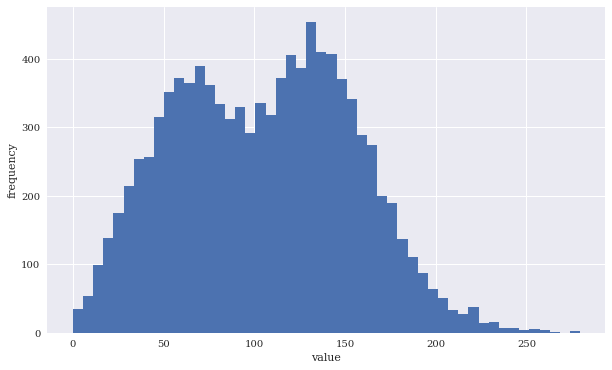

In [50]:
plt.figure(figsize=(10,6))
plt.hist(S[-1], bins=50)
plt.xlabel('value')
plt.ylabel('frequency');

*Figure 12-13. Dynamically simulated jump diffusion process at maturity*

The negative jumps can also be spotted in the first 10 simulated index level paths, as presented in Figure 12-14:

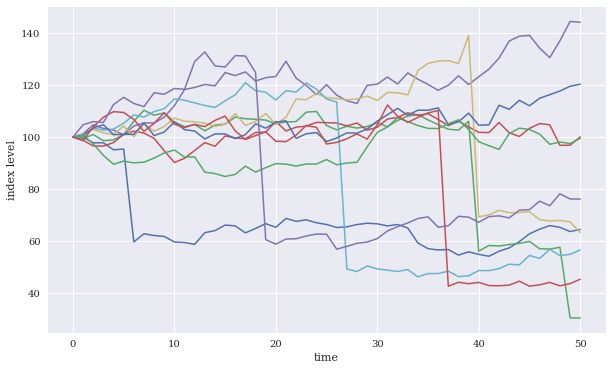

In [51]:
plt.figure(figsize=(10,6))
plt.plot(S[:, :10], lw=1.5)
plt.xlabel('time')
plt.ylabel('index level');

*Figure 12-14. Dynamically simulated jump diffusion process paths*

## Variance Reduction
Because the Python functions used so far generate *pseudo-random* numbers and due to the varying sizes of the samples drawn, the resulting sets of numbers might not exhibit statistics close enough to the expected or desired ones. For example, one would expect a set of standard normally distributed random numbers to show a mean of 0 and a standard deviation of 1. Let us check what statistics different sets of random numbers exhibit. To achieve a realistic comparison, the seed value for the random number generator is fixed:

In [52]:
print('%15s %15s' % ('Mean', 'Std. Deviation'))
print(31 * '-')
for i in range(1, 31, 2):
    npr.seed(100)
    sn = npr.standard_normal(i ** 2 * 10000)
    print('%15.12f %15.12f' % (sn.mean(), sn.std()))

           Mean  Std. Deviation
-------------------------------
 0.001150944833  1.006296354600
 0.002841204001  0.995987967146
 0.001998082016  0.997701714233
 0.001322322067  0.997771186968
 0.000592711311  0.998388962646
-0.000339730751  0.998399891450
-0.000228109010  0.998657429396
 0.000295768719  0.998877333340
 0.000257107789  0.999284894532
-0.000357870642  0.999456401088
-0.000528443742  0.999617831131
-0.000300171536  0.999445228838
-0.000162924037  0.999516059328
 0.000135778889  0.999611052522
 0.000182006048  0.999619405229


In [53]:
i ** 2 * 10000

8410000

The results here show that the statistics "somehow" get better the larger the number of draws becomes. However, they still do not match the desired ones, even in our largest sample with more than 8,000,000 random numbers.

Fortunately, there are easy-to-implement, generic variance reduction techniques available to improve the matching of the first two moments of the (standard) normal distribution. The first technique is to use *antithetic variates*. This approach simply draws only half the desired numbe of random draws, and adds the same set of random numbers with the opposite sign afterward. For example, if the random number generator (i.e., the respective Python function) draws 0.5, then another number with the value -0.5 is added to the set. By construction, the mean value of such a data set must equal zero.

With NumPy this is consicely implemented by using the function np.concatenate(). The following repeats the exercise from before, this time using antithetic variates:

In [54]:
sn = npr.standard_normal(int(1000 / 2))
sn = np.concatenate((sn, -sn))

In [55]:
np.shape(sn)

(1000,)

In [56]:
sn.mean()

-1.7763568394002505e-18

In [57]:
print('%15s %15s' % ('Mean', 'Std. Deviation'))
print(31 * "-")
for i in range(1, 31, 2):
    npr.seed(1000)
    sn = npr.standard_normal(i ** 2 * int(10000 / 2))
    sn = np.concatenate((sn, -sn))
    print("%15.12f %15.12f" % (sn.mean(), sn.std()))

           Mean  Std. Deviation
-------------------------------
 0.000000000000  1.009653753942
-0.000000000000  1.000413716783
 0.000000000000  1.002925061201
-0.000000000000  1.000755212673
 0.000000000000  1.001636910076
-0.000000000000  1.000726758438
-0.000000000000  1.001621265149
 0.000000000000  1.001203722778
-0.000000000000  1.000556669784
-0.000000000000  1.000113464185
-0.000000000000  0.999435175324
-0.000000000000  0.999356961431
-0.000000000000  0.999641436845
-0.000000000000  0.999642768905
-0.000000000000  0.999638303451


This approach corrects the first moment perfectly -- which should not come as a surprise due to the very construction of the data set. However, this approach does not have any influence on the second moment, the standard deviation. Using another variance reduction technique, called *moment matching*, helps correct in one step both the first and second moments: 

In [58]:
sn = npr.standard_normal(10000)

In [59]:
sn.mean()

-0.001165998295162494

In [60]:
sn.std()

0.991255920204605

In [61]:
sn_new = (sn - sn.mean()) / sn.std()

In [62]:
sn_new.mean()

-2.3803181647963357e-17

In [63]:
sn_new.std()

0.9999999999999999

By subtracting the mean from every single random number and dividing every single number by the standard deviation, this technique ensures that the set of random numbers matches the desired first and second moments of the standard normal distribution (almost) perfectly.

The following function utilizes the insight with regard to variance reduction techniques and generates standard normal random numbers for process simulation using either two, one, or no variance reduction technique(s):

In [64]:
def gen_sn(M, I, anti_paths=True, no_match=True):
    ''' Function to generate random numbers for simulation.
    
    Parameters
    ==========
    M: int
        number of time intervals for discretization
    I: int
        number of paths to be simulated
    anti_paths: boolean
        use of antithetic variates
    no_match: boolean
        use of moment matching
    '''
    if anti_paths is True:
        sn = npr.standard_normal((M + 1, int(I / 2)))
        sn = np.concatenate((sn, -sn), axis=1)
    else:
        sn = npr.standard_normal((M + 1, I))
    if no_match is True:
        sn = (sn - sn.mean()) / sn.std()
    return sn

Vectorization with NumPy is a natural, concise, and efficient approach to implementing Monte Carlo simulation algorithms in Python. However, using NumPy vectorization comes with a larger memory footprint in general. For alternatives that might be equally fast, see Chapter 10.

## Valuation
One of the most important applications of Monte Carlo simulation is the *valuation of contingent claims* (options, derivatives, hybird instruments, etc..). Simply stated, in a risk-neutral world, the value of a contingent claim is the discounted expected payoff under the risk-neutral (martingale) measure. This is the probability measure that makes all risk factors (stocks, indicies, etc.) drift at the riskless short rate, making the discounted processes martingales. According to the Fundamental Theorem of Asset Pricing, the existince of such a probability measure is the equivalent to the absence of arbitrage.

A financial option embodies the right to buy (*call option*) or sell (*put option*) a specified financial instrument at a given maturity date (*European option*), or over a specified period of time (*American Option*), at a given price (*strike price*). Let us first consider the simpler case of European options in terms of valuation.

## Eurpoean Options
The payoff of a European call option on an index at maturity is given by $h(S_T) \equiv max(S_T - K,0)$, where $S_T$ is the index level at maturity date $T$ and $K$ is the strike price. Given a, or in complete markets *the*, risk-neutral measure for the relevant stochastic process (e.g., geometric Brownian motion), the price of such an option is given by the formula in Equation 12-10.

*Equation 12-10. Pricing by risk-neutral expectation*

$C_0 = e^{-rT}E^Q_0(h(S_T)) = e^{-rT}\int_{0}^{\infty}h(s)q(s)ds$

Chapter 11 sketches how to numerically evaluate an integral by Monte Carlo simulation. This approach is used in the following and applied to Equation 12-10. Equation 12-11 provides the respective Monte Carlo estimator for the European option, where $\tilde{S_T^i}$ is the $T$th simulated index level at maturity.

*Equation 12-11. Risk-neutral Monte Carlo estimator*

$\widetilde{C_0} = e^{-rT}\frac{1}{I}\sum\limits^{I}_{i = 1}h(\tilde{S^i_T})$

Consider now the following parameterization for the geometric Brownian motion and the valuation functiongbm_mcs_stat(), taking as a parameter only the strike price. Here, only the index level at maturity is simulated. As a reference, consider the case with a strike price of $K = 105$:

In [65]:
S0 = 100
r = 0.05
sigma = 0.25
T = 1.0
I = 50000

In [66]:
def gbm_mcs_stat(K):
    ''' Valuation of European call option in Black-Scholes-Merton
    by Monte Carlo simulation (of index level at maturity)
    
    Parameters
    ==========
    k: float
        (positive) strike price of the option
    
    Returns
    =======
    C0: float
        estimated present value of European call option
    '''
    sn = gen_sn(1, I)
    # simulate index level at maturity
    ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T
                    + sigma * math.sqrt(T) * sn[1])
    # calculate payoff at maturity
    hT = np.maximum(ST - K, 0)
    # calculate MCS estimator
    C0 = math.exp(-r * T) * np.mean(hT)
    return C0

In [67]:
gbm_mcs_stat(K=105.)

10.044221852841922

Next, consider the dynamic simulation approach and allow for European put options in addition to the call option. The function gbm_mcs_dyna() implements the algorithm. The code also compares option price estimates for a call and a put stroke at the same level:

In [68]:
M = 50

In [69]:
def gbm_mcs_dyna(K, option='call'):
    ''' Valuation of European options in Black-Scholes-Merton 
    by Monte Carlo simulation (of index level paths)
    
    Parameters
    ==========
    K: float
        (positive) strike price of the option
    option: string
        type of the option to be valued ('call', 'put')
        
    Returns
    =======
    C0: float
        estimated present value of European call option
    '''
    dt = T / M
    # simulation of index level paths
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt
                                + sigma * math.sqrt(dt) * sn[t])
    # case-based calculation of payoff
    if option == 'call':
        hT = np.maximum(S[-1] - K, 0)
    else:
        hT = np.maximum(K - S[-1], 0)
    # calculation of MCS estimator
    C0 = math.exp(-r * T) * np.mean(hT)
    return C0

In [70]:
gbm_mcs_dyna(K=110., option='call')

7.950008525028434

In [71]:
gbm_mcs_dyna(K=110., option='put')

12.629934942682004

The question is how well these simulation-based valuation approaches perform relative to the benchmark value from the Black-Scholes-Merton valuation formula. To find out, the following code generates respective option values/estimates for a range of strike prices, using the analytical option pricing formula for European calls found in the module bsm_functions.py (see the script stored in this folder).

First, we compare the results from the static simulation approach with precise analytical values:

In [72]:
from bsm_functions import bsm_call_value

In [73]:
# instantiates lists to store results
stat_res = []
dyna_res = []
anal_res = []
# range of strike prices
k_list = np.arange(80., 120.1, 5.)
np.random.seed(100)

In [74]:
for K in k_list:
    # simulation to collect option values across strike prices
    stat_res.append(gbm_mcs_stat(K))
    dyna_res.append(gbm_mcs_dyna(K))
    anal_res.append(bsm_call_value(S0, K, T, r, sigma))

In [75]:
# transform results into ndarrys
stat_res = np.array(stat_res)
dyna_res = np.array(dyna_res)
anal_res = np.array(anal_res)

Figure 12-5 shows the results. All valuation differences are smaller than 1% absolutely. There are both negative and positive value differences:

<Figure size 720x432 with 0 Axes>

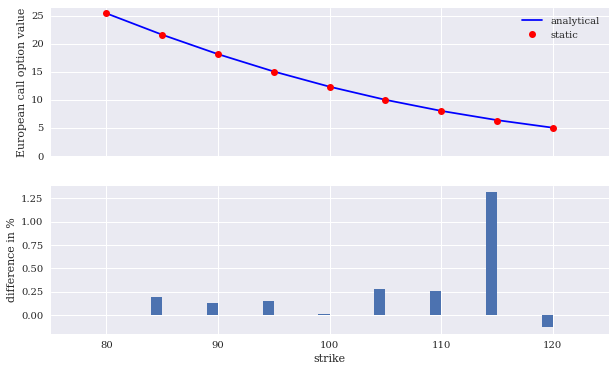

In [76]:
plt.figure(figsize=(10,6))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,6))
ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, stat_res, 'ro', label='static')
ax1.set_ylabel('European call option value')
ax1.legend(loc=0)
ax1.set_ylim(bottom=0)
wi = 1.0
ax2.bar(k_list - wi / 2, (anal_res - stat_res) / anal_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125);

*Figure 12-15. Analytical option values vs. Monte Carlo estimators (static simulation)*

A smaller picture emerges for the dynamic simulation and valuation approach, whose results are reported in Figure 12-16. Again, all valuation differences are smaller than 1% absolutely, with both positive and negative deviations. As a general rule, the quality of the Monte Carlo estimator can be controlled for by adjusting the number of time intervals $M$ used and/or the number of paths $I$ simulated:

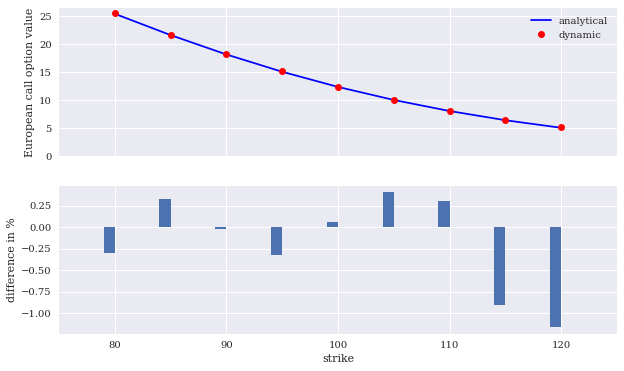

In [77]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(k_list, anal_res, 'b', label='analytical')
ax1.plot(k_list, dyna_res, 'ro', label='dynamic')
ax1.set_ylabel('European call option value')
ax1.legend(loc=0)
ax1.set_ylim(bottom=0)
wi = 1.0
ax2.bar(k_list - wi / 2, (anal_res - dyna_res) / anal_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('difference in %')
ax2.set_xlim(left=75, right=125);

*Figure 12-16. Analytical option values vs Monte Carlo estimators (dynamic simulation)*

## American Options
The valuation of American options is more involved compared to European options. In this case, an *optimal stopping* problem has to be solved to come up with a fair value of the option. Equation 12-12 formulates the valuation of an American option as such a problem. The problem formulation is already based on a discrete time grid for use with numerical simulation. In a sense, it is therefore more correct to speak of an option value given *Bermudan* exercise. For the time interval converging to zero length, the value of the Bermudan option converges to the one of the American option.

*Equation 12-12. American option prices as optimal stopping problem*

$V_0 = \underset{\tau \in \{0, \Delta t, 2\Delta t, \dots, T\}}{\sup} e^{-rT}E^Q_0(h_\tau(S_\tau))$

The algorithm described in the following is called *Least-Squares Monte Carlo* (LSM) and is from the paper by Longstaff and Schwartz (2001). It can be shown that the value of an American (Bermudan) option at any given date *t* is given as $V_t(s) = max(h_t(s), C_t(s))$, where $C_t(s) = E^Q_t(e^{-r \Delta t}V_{t + \Delta t}(S_{t + \Delta t}| S_t = s)$ is the so-called *continuation value* of the option given an index level of $S_t = s$.

Consider now that we have simulated $I$ paths of the index level over $M$ time intervals of equal size $\Delta t$. Define $Y_{t, i} \equiv e^{-r\Delta t}V_{t+\Delta t, i}$ to be the simulated continuation value for path $i$ at time $t$. We cannot use this number directly because it would imply perfect foresight. However, we can use the cross section of all such simulated continuation values to estimate the (expected) continuation value by least-squares regression.

Given a set of basis functions, $b_d, d = 1, \dots, D$, the continuation value is then given by the regression estimate $\hat{C}_{t,i} = \Sigma^{D}_{d=1} \alpha^*_{d,t} \cdot b_d(S_{t,i})$, where the optimal regression parameters $\alpha^*$ are the solution of the least-squares problem stated in Equation 12-13.

*Equation 12-13. Least-squares regression for American option valuation*

$\underset{\alpha_{1,t}, \dots, \alpha_{D,t}}{\min} \frac{1}{I} \sum\limits^{I}_{i=1} (Y_{t,i} - \sum\limits^{D}_{d = 1} \alpha_{d,t} \cdot b_d (S_{t,i}))^2$

The function gbm_mcs_amer() implements the LSM algorithm for both American call and put options:

In [78]:
def gbm_mcs_amer(K, option='call'):
    ''' Valuation of American option in Black-Scholes-Merton 
    by Monte Carlo simulation by LSM algorithm
    
    Parameters
    ==========
    K: float
        (positive) strike price of the option
    option: string
        type of the option to be valued ('call', 'put')
        
    Returns
    =======
    C0: float
        estimated present value of American call option
    '''
    dt = T / M
    df = math.exp(-r * dt)
    # simulation of index levels
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn = gen_sn(M, I)
    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * sigma ** 2) * dt 
                                + sigma * math.sqrt(dt) * sn[t])
    # case based calculation of payoff
    if option == 'call':
        h = np.maximum(S - K, 0)
    else:
        h = np.maximum(K - S, 0)
    # LSM algorithm
    V = np.copy(h)
    for t in range(M - 1, 0, -1):
        reg = np.polyfit(S[t], V[t + 1] * df, 7)
        C = np.polyval(reg, S[t])
        V[t] = np.where(C > h[t], V[t + 1] * df, h[t])
    # MCS estimator
    C0 = df * np.mean(V[1])
    return C0

In [79]:
gbm_mcs_amer(110., option='call')

7.721705606305353

In [80]:
gbm_mcs_amer(110., option='put')

13.609997625418051

The European value of an option represents a lower bound to the American option's value. The difference is generally called the *early exercise premium*. What follows compares the European and American option values for the same range of strikes as before to estimate the early exercise premium, this time with puts.

In [81]:
euro_res = []
amer_res = []

In [82]:
k_list = np.arange(80., 120.1, 5.)

In [83]:
for K in k_list:
    euro_res.append(gbm_mcs_dyna(K, 'put'))
    amer_res.append(gbm_mcs_amer(K, 'put'))

In [84]:
euro_res = np.array(euro_res)
amer_res = np.array(amer_res)

Figure 12-17 shows that for the range of strikes chosen the early exercise premium can rise to up to 10%:

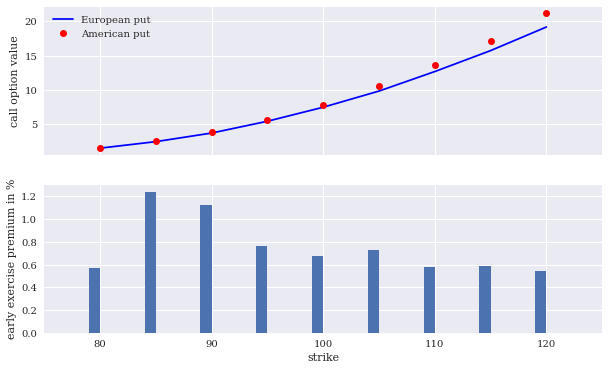

In [85]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(k_list, euro_res, 'b', label='European put')
ax1.plot(k_list, amer_res, 'ro', label='American put')
ax1.set_ylabel('call option value')
ax1.legend(loc=0)
wi = 1.0
ax2.bar(k_list - wi / 2, (amer_res - euro_res) / euro_res / euro_res * 100, wi)
ax2.set_xlabel('strike')
ax2.set_ylabel('early exercise premium in %')
ax2.set_xlim(left=75, right=125);

*Figure 12-17. European vs American Monte Carlo estimators*

## Risk Measures
In addition to valuation, *risk management* is another important application area of stochastic methods and simulation. This section illustrates the calculation/estimation of two of the most common risk measures applied today in the finance industry.

### Value-at-Risk
*Value-at-risk* (VaR) is one of the most widely used risk measures, and a much debated one. Loved by practitioners for its intuitive appeal, it is widely discussed and criticized by many - mainly on theoretical grounds, with regard to its limited ability to capture what is called *tail risk* (more on this shortly). In other words, VaR is a number denoted in currency units (e.g., USD, EUR, JPY) indicating a loss (of a portfolio, a single position, etc.) that is not exceeded with some confidence level (probability) over a given period of time.

Consider a stock position, worth 1 million USD today, that has a VaR of 50,000 USD at a confidence level of 99% over a time period of 30 days (one month). This VaR figure says that with a probability o 99% (i.e., in 99 out of 100 cases), the loss to be expected over a period of 30 days will *not exceed* 50,000 USD. However, it does not say anything about the size of the loss once a loss beyond 50,000 USD occurs -- i.e., if the maximum loss is 100,000 or 500,000 USD what the probability of such a specific "higher than VaR loss" is. All it says is that there is a 1% probability that a loss of a *minimum of 50,000 USD or higher* will occur.

Assume the Black-Scholes-Merton setup and consider the following parameterization and simulation of index levels at a future date $T = 30/365$ (a period of 30 days). The estimation of VaR figures requires the simulated absolute profits and losses relative to the value of the position today in a sorted manner, i.e., from the severest loss to the largest profit. Figure 12-18 shows the histogram of the simulated absolute performance values:

In [86]:
S0 = 100
r = 0.5
sigma = 0.25
T = 30 / 365
I = 10000

In [87]:
ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T +
                sigma * np.sqrt(T) * npr.standard_normal(I))

In [88]:
R_gbm = np.sort(ST - S0)

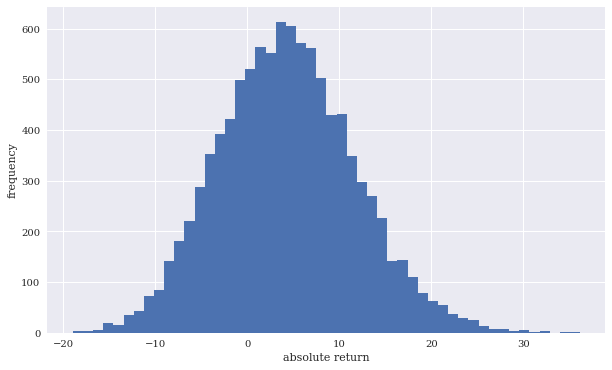

In [89]:
plt.figure(figsize=(10,6))
plt.hist(R_gbm, bins=50)
plt.xlabel('absolute return')
plt.ylabel('frequency');

*Figure 12-18. Absolute profits and losses from simulation (geometric Brownian motion)*

Having the ndarray object with the sorted results, the scs.scoreatpercentile() function already does the trick. All one has to do is to define the percentiles of interest (in percent values). In the list objects percs, 0.1 translates into a confidence level of 100% - 0.1% = 99.9%. In the list object percs, 0.1 translates into a confidence level off 100% - 0.1% = 99.9%. The 30 day VaR given a confidence level of 99.9% in this case is 18.8 currency units, while it is 8.5 at the 90% confidence level:

In [90]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var = scs.scoreatpercentile(R_gbm, percs)
print('%16s %16s' % ('Confidence Level', 'Value-at-Risk'))
print(33 * '-')
for pair in zip(percs, var):
    print('%16.2f %16.3f' % (100 - pair[0], -pair[1]))

Confidence Level    Value-at-Risk
---------------------------------
           99.99           18.868
           99.90           15.779
           99.00           12.036
           97.50            9.531
           95.00            7.464
           90.00            5.057


As a second example, recall the jump diffusion setup from Merton, which is simulated dynamically. In this case, with the jump component having a negative mean, one sees something like a bimodal distribution point of view, one sees a pronounced left *fat tail*:

In [91]:
dt = 30. / 365 / M
rj = lamb * (math.exp(mu + 0.5 * delta ** 2) - 1)

In [92]:
S = np.zeros((M + 1, I))
S[0] = S0
sn1 = npr.standard_normal((M + 1, I))
sn2 = npr.standard_normal((M + 1, I))
poi = npr.poisson(lamb * dt, (M + 1, I))
for t in range(1, M + 1, 1):
    S[t] = S[t - 1] * (np.exp((r - rj - 0.5 * sigma ** 2) * dt 
                        + sigma * math.sqrt(dt) * sn1[t]) 
                        + (np.exp(mu + delta * sn2[t]) - 1)
                        * poi[t])
    S[t] = np.maximum(S[t], 0)

In [93]:
R_jd = np.sort(S[-1] - S0)

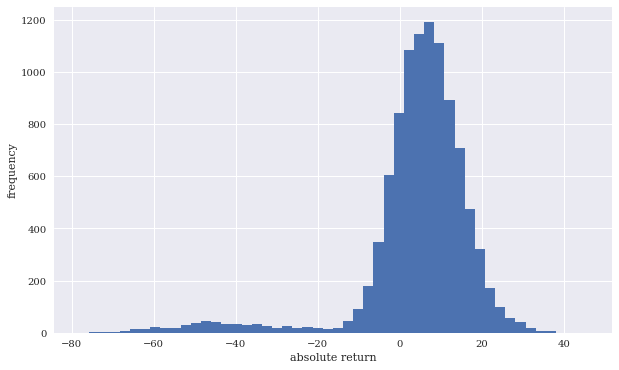

In [94]:
plt.figure(figsize=(10, 6))
plt.hist(R_jd, bins=50)
plt.xlabel('absolute return')
plt.ylabel('frequency');

*Figure 12-19. Absolute profits and losses from simulation (jump diffusion)*

For this process and parameterization, the VaR over 30 days at the 90% level is almost identical as with the geometric Brownian motion, while it is more than *three times* as high at the 99.9% level (70 vs 18.8 currency units):

In [95]:
percs = [0.01, 0.1, 1., 2.5, 5.0, 10.0]
var = scs.scoreatpercentile(R_jd, percs)
print('%16s %16s' % ('Confidnece Level', 'Value-at-Risk'))
print(33 * '-')
for pair in zip(percs, var):
    print('%16.2f %16.3f' % (100 - pair[0], -pair[1]))

Confidnece Level    Value-at-Risk
---------------------------------
           99.99           75.598
           99.90           68.189
           99.00           54.273
           97.50           44.347
           95.00           21.317
           90.00            5.401


This illustrates the problem of capturing the tail risk so often encountered in financial markets by the standard VaR measure.

To further illustrate the point, Figure 12-20 lastly shows the VaR measures for both cases in direct comparison graphically. As the plot reveals, the VaR measures behave completely differently given a range of typical confidence levels:

In [96]:
percs = list(np.arange(0.0, 10.1, 0.1))
gbm_var = scs.scoreatpercentile(R_gbm, percs)
jd_var = scs.scoreatpercentile(R_jd, percs)

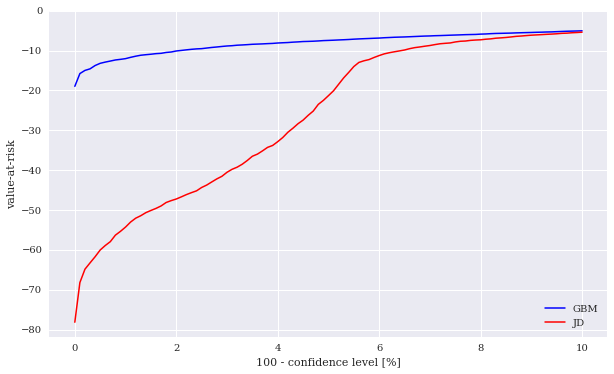

In [97]:
plt.figure(figsize=(10, 6))
plt.plot(percs, gbm_var, 'b', lw=1.5, label='GBM')
plt.plot(percs, jd_var, 'r', lw=1.5, label='JD')
plt.legend(loc=4)
plt.xlabel('100 - confidence level [%]')
plt.ylabel('value-at-risk')
plt.ylim(ymax=0.0);

*Figure 12-20. Value-at-risk for geometric Brownian motion and jump diffusion*

### Credit Valuation Adjustments
Other important risk measures are the credit value-at-risk (CVaR) and the credit valuation adjustment (CVA), which is derived from the CVaR. Roughly speaking, CVaR is a measure for the risk resulting from the possibility that a counterparty might not be able to honor its obligations -- for example, if the counterparty goes bankrupt. In such a case there are two main assumptions to be made: the *probability of default* and the (average) *loss level*. To make it specific, consider again the benchmark setup of Black-Scholes-Merton with the parameterization in the following code. In the simplest case, one considers a fixed (average) loss level $L$ and a fixed probability $p$ of default (per year) of a counter-party. Using the Poisson distribution, default scenarios are generated as follows, taking into account that a default can only occur once:

In [98]:
S0 = 100.
r = 0.05
sigma = 0.2
T = 1.
I = 100000

In [99]:
ST = S0 * np.exp((r - 0.5 * sigma ** 2) * T 
                + sigma * np.sqrt(T) * npr.standard_normal(I))

In [100]:
# defines the loss level
L = 0.5

In [101]:
# defines probability of default
p = 0.01

In [102]:
# simulates default events
D = npr.poisson(p * T, I)

In [103]:
# limits to one default event
D = np.where(D > 1, 1, D)

Without default, the risk-neutral value of the future index level should be equal to the current value of the asset today (up to differences resulting from numerical errors). The CVaR and the present value of the asset, adjusted for the credit risk, are given as follows:

In [104]:
# discounted average simulated value of the asset at T
math.exp(-r * T) * np.mean(ST)

99.94767178982691

In [105]:
# CVaR as the discounted average of the future losses in the case of a default
CVaR = math.exp(-r * T) * np.mean(L * D * ST)
CVaR

0.4883560258963962

In [106]:
# Discounted average simulated value of the asset at T, adjusted for the simulated losses from default
S0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * ST)
S0_CVA

99.45931576393053

In [107]:
# Current price of the asset adjusted by the simulated CVaR
S0_adj = S0 - CVaR
S0_adj

99.5116439741036

In this example, roughly 1,000 losses due to credit risk, which is to be expected given the assumed default probability of 1% and 100,000 simulated paths. Figure 12-21 shows the complete frequency distribution of the losses due to a default. Of course, in the large majority of cases (i.e., in about 99,000 of the 100,000 cases) there is no loss to observe:

In [108]:
# number of default events and therewith loss events
np.count_nonzero(L * D * ST)

978

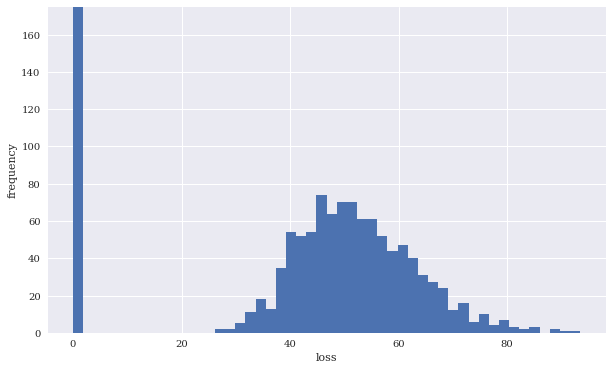

In [109]:
plt.figure(figsize=(10,6))
plt.hist(L * D * ST, bins=50)
plt.xlabel('loss')
plt.ylabel('frequency')
plt.ylim(ymax=175);

*Figure 12-21. Losses due to risk-neutrally expected default (stock)*

Consider now the case of a European call option. Its value is about 10.4 currency units at a strike of 100. The CVaR is about 5 cents given the same assumptions with regard to probability of default and loss level:

In [110]:
K = 100.
hT = np.maximum(ST - K, 0)

In [111]:
# monte carlo estimator value for European call option
C0 = math.exp(-r * T) * np.mean(hT)
C0

10.396916492839354

In [112]:
# CVaR as discounted average of the future losses in the case of a default
CVaR = math.exp(-r * T) * np.mean(L * D * hT)
CVaR

0.05159099858923533

In [113]:
# monte carlo estimator value for European call option, adjusted for the simulated losses from default
C0_CVA = math.exp(-r * T) * np.mean((1 - L * D) * hT)
C0_CVA

10.34532549425012

Compared to the case of a regular asset, the option case has somewhat different characteristics. One only sees a little more than 500 losses due to a default, although there are again 1,000 defaults in total. This results from the fact that the payoff of the option at maturity has a high probability of being zero. Figure 12-22 shows that the CVaR for the option has quite a different frequency distribution compared to the regular asset case:

In [114]:
# number of losses due to default
np.count_nonzero(L * D * hT)

538

In [115]:
# number of defaults
np.count_nonzero(D)

978

In [116]:
# cases where the option expires worthless
I - np.count_nonzero(hT)

44123

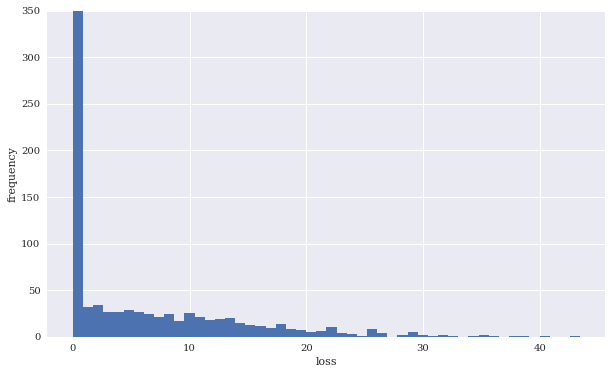

In [117]:
plt.figure(figsize=(10,6))
plt.hist(L * D * hT, bins=50)
plt.xlabel('loss')
plt.ylabel('frequency')
plt.ylim(ymax=350);

*Figure 12-22. Losses due to risk-neutrally expected default (call option)*

## Conclusions
This chapter described methods and techniques important to applying Monte Carlo simulation in finance. Specifically, the chapter walked through how to generate pseudo-random numbers based on different distribution laws. It proceeds with the simulation of random variables and stochastic processes, which is important in many financial areas. Two application areas are discussed in some depth in this chapter: valuation of options with European and American exercise and the estimation of risk measures like value-at-risk and credit valuation adjustments.

This chapter illustrates that Python in combination with NumPy is well suited to implementing even such computationally demanding tasks as valuation of American options by Monte Carlo simulation. This is mainly due to the fact that the majority of functions and classes of NumPy are implemented in C, which leads to considerable speed advantages in general over pure Python code. A further benefit is the compactness and readability of the resulting code due to vectorized operations.

## Further Resources

Black, Fischer, and Myron Scholes (1973). "The Pricing of Options and Corporate Liabilities." *Journal of Political Economy*, Vol.81, No.3, [pp.637-654.](https://www.cs.princeton.edu/courses/archive/fall09/cos323/papers/black_scholes73.pdf)